# Introduction

### What is a Random Matrix? 

Simply putting it, it is a matrix whose elements are drawn from a probability distribution (e.g. Gaussian, Uniform, Poisson, etc).

Random Matrix Theory (RMT) is the study of statistical properties of matrices with random entries. It focuses on ensembles of matrices and investigates patterns that emerge when the matrix size becomes significantly large.

# Testing

Using a range of tickers from a variety of US industries, the relationship's between each ticker can be visualised as below.

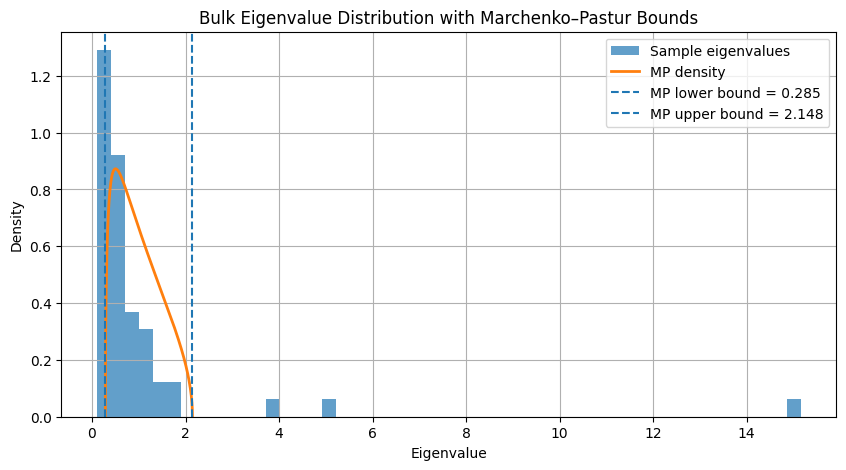

Number of signal eigenvalues: 3
Signal eigenvalues: [15.16172671  5.13180933  3.86035688]


In [ ]:
from data import fetch_prices, compute_returns, clean_returns
from spectrum import correlation_matrix, eigen_spectrum
from mp import mp_bounds, mp_pdf

import matplotlib.pyplot as plt
import numpy as np


tickers = [
    # Tech
    "AAPL","MSFT","GOOGL","AMZN","META","NVDA","TSLA","ADBE","CRM","ORCL",

    # Financials
    "JPM","BAC","WFC","C","GS","MS","BLK","AXP",

    # Healthcare
    "JNJ","PFE","MRK","ABBV","LLY","UNH","TMO","BMY",

    # Consumer
    "PG","KO","PEP","WMT","COST","MCD","NKE","SBUX","HD","LOW",

    # Industrials
    "CAT","BA","GE","HON","UPS","RTX","LMT",

    # Materials
    "LIN","APD","FCX","NEM",

    # Semiconductors
    "AMD","INTC","QCOM","AVGO","TXN","MU","ASML"
]

prices = fetch_prices(
    tickers=tickers,
    start="2023-01-01",
    end="2024-01-01",
)

returns = compute_returns(prices, log=True)
returns_clean = clean_returns(returns, threshold=0.95)
corr = correlation_matrix(returns_clean)

# Eigen spectrum
eigenvalues, eigenvectors = eigen_spectrum(corr)

# MP bounds and density
n_obs, n_assets = returns_clean.shape
lambda_min, lambda_max = mp_bounds(n_assets=n_assets, n_obs=n_obs)
x = np.linspace(lambda_min, lambda_max, 500)
mp_density = mp_pdf(x, n_assets=n_assets, n_obs=n_obs)

# Plot eigenvalue histogram + MP density + MP bounds
plt.figure(figsize=(10, 5))
plt.hist(eigenvalues, bins=50, density=True, alpha=0.7, label="Sample eigenvalues")
plt.plot(x, mp_density, linewidth=2, label="MP density")
plt.axvline(lambda_min, linestyle="--", label=f"MP lower bound = {lambda_min:.3f}")
plt.axvline(lambda_max, linestyle="--", label=f"MP upper bound = {lambda_max:.3f}")
plt.xlabel("Eigenvalue")
plt.ylabel("Density")
plt.title("Bulk Eigenvalue Distribution with Marchenko–Pastur Bounds")
plt.legend()
plt.grid(True)
plt.show()

signal_eigs = eigenvalues[eigenvalues > lambda_max]
print("Number of signal eigenvalues:", len(signal_eigs))
print("Signal eigenvalues:", signal_eigs[:10])

We can see that there are 3 key eigenvalues that lie significantly outside the Marchenko–Pastur (MP) bounds. These represent genuine structure in the data rather than random noise. The largest eigenvalue corresponds to the overall market mode, while the remaining significant eigenvalues likely capture sectoral and macroeconomic factors.

In contrast, the bulk of the eigenvalues falls within the MP bounds, indicating that these components are largely driven by noise. This clear separation between signal and noise is the key insight provided by Random Matrix Theory and forms the basis for denoising the correlation matrix.

Having identified the eigenvalues that lie outside the Marchenko–Pastur bounds, the next step is to reconstruct a denoised correlation matrix. The significant eigenvalues are retained as signal while eigenvalues within the MP bulk are treated as noise and replaced with a shrinkage estimate. This produces a more stable estimate of correlation structure for downstream trading applications.

### Stability Analysis

To evaluate the effectiveness of denoising, we compare correlation matrices across two time periods. Higher similarity indicates more stable and reliable estimates.

In [22]:
from denoise import denoise_correlation_matrix

corr_denoised = denoise_correlation_matrix(
    corr,
    eigenvalues,
    eigenvectors,
    lambda_max
)

mid = len(returns_clean) // 2
returns_1 = returns_clean.iloc[:mid]
returns_2 = returns_clean.iloc[mid:]

corr_1 = correlation_matrix(returns_1)
corr_2 = correlation_matrix(returns_2)

eigenvalues_1, eigenvectors_1 = eigen_spectrum(corr_1)
eigenvalues_2, eigenvectors_2 = eigen_spectrum(corr_2)

n_obs_1, n_assets_1 = returns_1.shape
n_obs_2, n_assets_2 = returns_2.shape

_, lambda_max_1 = mp_bounds(n_assets=n_assets_1, n_obs=n_obs_1)
_, lambda_max_2 = mp_bounds(n_assets=n_assets_2, n_obs=n_obs_2)

corr_1_d = denoise_correlation_matrix(
    corr_1,
    eigenvalues_1,
    eigenvectors_1,
    lambda_max_1
)

corr_2_d = denoise_correlation_matrix(
    corr_2,
    eigenvalues_2,
    eigenvectors_2,
    lambda_max_2
)

raw_corr = np.corrcoef(
    corr_1.values.flatten(),
    corr_2.values.flatten()
)[0, 1]

den_corr = np.corrcoef(
    corr_1_d.values.flatten(),
    corr_2_d.values.flatten()
)[0, 1]

print("Raw stability:", raw_corr)
print("Denoised stability:", den_corr)


Raw stability: 0.7725887443904325
Denoised stability: 0.8255885850013263


The denoised correlation matrix exhibits higher stability, suggesting that RMT filtering successfully reduces noise.

### Pair Selection

We select candidate trading pairs from the denoised correlation matrix. Highly correlated pairs are more likely to exhibit mean reverting behavior.

          pair      corr  spread_std  zscore_std  crossings
0      BAC - C  0.562507    0.052050    1.245252         23
1    BAC - WFC  0.557748    0.050973    1.167674         31
2      C - WFC  0.556292    0.057946    1.265837         22
3    BAC - JPM  0.543979    0.083430    1.380303         20
4    JPM - WFC  0.538844    0.047625    1.257846         19
5      C - JPM  0.538620    0.072452    1.298677         22
6       C - MS  0.538462    0.046293    1.314386         19
7     BAC - MS  0.532903    0.049742    1.321986         24
8    BAC - CAT  0.528071    0.082689    1.375080         24
9  ADBE - ASML  0.526384    0.202191    1.255869         21
Selected pair: BAC C
              zscore   long  short  exit   stop
Date                                           
2023-02-01 -0.070943  False  False  True  False
2023-02-02  0.173470  False  False  True  False
2023-02-13  0.314552  False  False  True  False
2023-02-14 -0.207589  False  False  True  False
2023-02-15 -0.444554  False  Fa

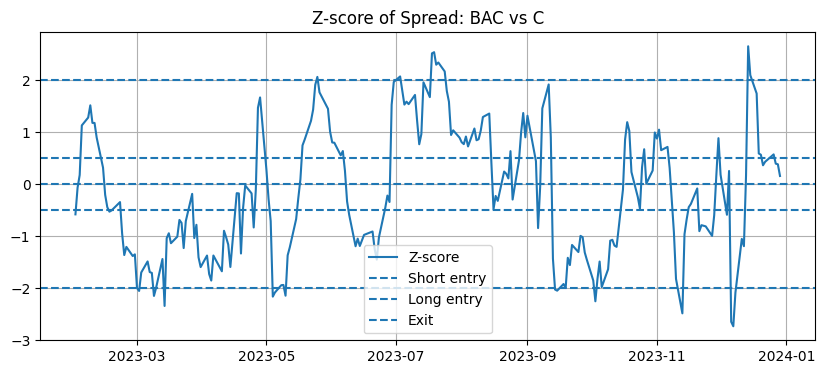

In [ ]:
from pairs import top_pairs, rank_pairs_by_spread_quality, compute_spread, compute_zscore, generate_signals
import matplotlib.pyplot as plt

candidate_pairs = top_pairs(corr_1_d, n=20)
ranked_pairs = rank_pairs_by_spread_quality(prices, candidate_pairs, top_n=10)

best_pair = ranked_pairs.iloc[0]["pair"]
asset_1, asset_2 = best_pair.split(" - ")

print("Selected pair:", asset_1, asset_2)

pair_prices = prices[[asset_1, asset_2]].dropna()

spread = compute_spread(pair_prices, asset_1, asset_2)
zscore = compute_zscore(spread, window=20)
signals = generate_signals(zscore, entry=2.0, exit=0.5)

plt.figure(figsize=(10, 4))
plt.plot(zscore.index, zscore.values, label="Z-score")
plt.axhline(2.0, linestyle="--", label="Short entry")
plt.axhline(-2.0, linestyle="--", label="Long entry")
plt.axhline(0.5, linestyle="--", label="Exit")
plt.axhline(-0.5, linestyle="--")
plt.axhline(0.0, linestyle="--")
plt.title(f"Z-score of Spread: {asset_1} vs {asset_2}")
plt.legend()
plt.grid(True)
plt.show()

### Strategy Backtest

We simulate a simple pairs trading strategy based on the generated signals and evaluate its performance over time.

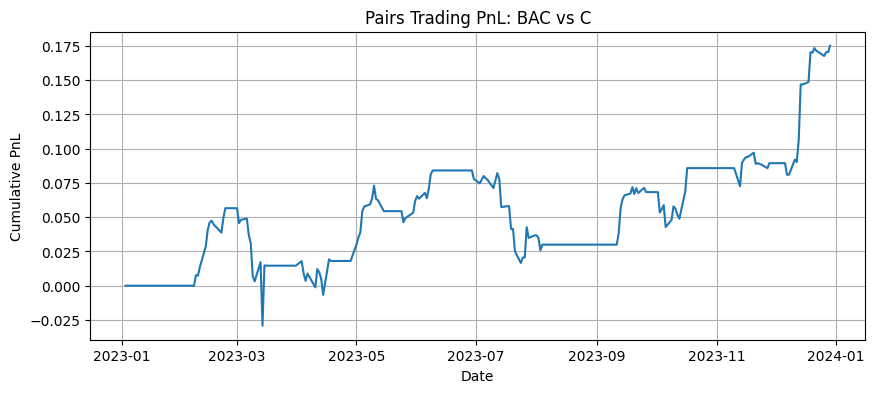

Total return: 0.1751747214358086
Mean return: 0.0007006988857432343
Std dev: 0.007791490575170773
Sharpe: 0.08993130120392612


In [24]:
from pairs import (
    top_pairs,
    rank_pairs_by_spread_quality,
    compute_spread,
    compute_zscore,
    generate_signals,
    backtest_pairs_strategy,
)

candidate_pairs = top_pairs(corr_1_d, n=20)
ranked_pairs = rank_pairs_by_spread_quality(prices, candidate_pairs, top_n=10)

best_pair = ranked_pairs.iloc[0]["pair"]
asset_1, asset_2 = best_pair.split(" - ")

pair_prices = prices[[asset_1, asset_2]].dropna()
spread = compute_spread(pair_prices, asset_1, asset_2)
zscore = compute_zscore(spread, window=20)

signals = generate_signals(zscore, entry=1.5, exit=0.0, stop=2.5)

positions, spread_returns, strategy_returns, cum_pnl, stats = backtest_pairs_strategy(
    spread,
    signals,
    max_holding=10
)

plt.figure(figsize=(10, 4))
plt.plot(cum_pnl.index, cum_pnl.values)
plt.title(f"Pairs Trading PnL: {asset_1} vs {asset_2}")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL")
plt.grid(True)
plt.show()

print("Total return:", stats["total_return"])
print("Mean return:", stats["mean_return"])
print("Std dev:", stats["std_dev"])
print("Sharpe:", stats["sharpe"])

### Strategy Performance

The cumulative PnL shows the profitability of the strategy. A smooth upward trend indicates stable mean reverting behavior, while large drawdowns highlight periods of model breakdown.

This pairs trade involves taking offsetting positions in two related assets to exploit temporary deviations in their relative pricing. For the BAC–C pair, both stocks are large US banks with similar economic drivers. When the spread between them deviates significantly from its historical mean, a long–short position is initiated assuming it reverts back to this mean. The trade is closed once the spread returns to equilibrium.